In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# For LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
df = pd.read_csv("gage02361000_NADA_all_cells.csv")

print(df.head())
print(df.info())


   year  flow_cfs  cell_1  cell_2  cell_3  cell_4  cell_5  cell_6  cell_7  \
0   365       NaN     NaN     NaN  -2.485  -2.394     NaN     NaN  -2.678   
1   366       NaN     NaN     NaN   0.178  -0.305     NaN     NaN  -0.116   
2   367       NaN     NaN     NaN   0.650   0.233     NaN     NaN   0.384   
3   368       NaN     NaN     NaN  -0.316  -0.337     NaN     NaN  -0.329   
4   369       NaN     NaN     NaN  -0.469  -0.510     NaN     NaN  -0.466   

   cell_8  ...  cell_9_lag1  cell_9_lag2  cell_10_lag1  cell_10_lag2  \
0  -2.870  ...          NaN          NaN           NaN           NaN   
1  -0.393  ...          NaN          NaN           NaN           NaN   
2   0.323  ...          NaN          NaN           NaN           NaN   
3  -0.305  ...          NaN          NaN           NaN           NaN   
4  -0.468  ...          NaN          NaN           NaN           NaN   

   cell_11_lag1  cell_11_lag2  cell_12_lag1  cell_12_lag2  cell_13_lag1  \
0           NaN           NaN

In [3]:
# Identify predictor columns
X = df[[c for c in df.columns if c.startswith("cell_")]]
y = df["flow_cfs"]

# Keep years for plotting
years = df["year"]


In [4]:
# Calibration: rows where flow is observed (non-NaN)
calibration_mask = ~y.isna()
X_cal = X[calibration_mask]
y_cal = y[calibration_mask]
years_cal = years[calibration_mask]

# Full reconstruction predictors (for later prediction)
X_full = X
years_full = years


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

# Impute missing values (NaN) in training and test data
# Use median imputation to handle missing values in predictor cells
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index
)

# Also impute full dataset for reconstruction
X_full_imputed = pd.DataFrame(
    imputer.transform(X_full), 
    columns=X_full.columns, 
)


In [6]:
# Initialize scaler for later use with MLP
scaler = StandardScaler()


In [7]:
## DATA QUALITY DIAGNOSTICS ##
print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# 1. Sample size
print(f"\n1. Sample Size:")
print(f"   Total observations with flow data: {len(X_cal)}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")
print(f"   Features: {X_train.shape[1]}")
print(f"   Ratio: {X_train.shape[0]/X_train.shape[1]:.1f} samples per feature")

# 2. Missing data pattern
print(f"\n2. Missing Data in Calibration Set:")
missing_pct = (X_cal.isna().sum() / len(X_cal) * 100).sort_values(ascending=False)
print(missing_pct)

# 3. Correlation analysis
print(f"\n3. Predictor-Target Correlations:")
correlations = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation': [X_train_imputed[col].corr(y_train) for col in X_train.columns]
}).sort_values('Correlation', key=abs, ascending=False)
print(correlations)
max_corr = correlations['Correlation'].abs().max()
print(f"\n   Max absolute correlation: {max_corr:.3f}")
if max_corr < 0.3:
    print("   ⚠️  WARNING: Low correlations suggest weak predictor-target relationship")

# 4. Target variable statistics
print(f"\n4. Target Variable (Flow) Statistics:")
print(f"   Mean: {y_train.mean():.2f} cfs")
print(f"   Std: {y_train.std():.2f} cfs")
print(f"   Min: {y_train.min():.2f} cfs")
print(f"   Max: {y_train.max():.2f} cfs")
print(f"   CV (Coefficient of Variation): {y_train.std()/y_train.mean():.2f}")

# 5. Baseline model (predict mean)
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"\n5. Baseline Model (predicting mean):")
print(f"   R² = {baseline_r2:.3f}")
print(f"   Models must beat this to be useful!")


DATA QUALITY ASSESSMENT

1. Sample Size:
   Total observations with flow data: 78
   Training samples: 62
   Test samples: 16
   Features: 39
   Ratio: 1.6 samples per feature

2. Missing Data in Calibration Set:
cell_1          0.0
cell_9_lag1     0.0
cell_5_lag2     0.0
cell_6_lag1     0.0
cell_6_lag2     0.0
cell_7_lag1     0.0
cell_7_lag2     0.0
cell_8_lag1     0.0
cell_8_lag2     0.0
cell_9_lag2     0.0
cell_4_lag2     0.0
cell_10_lag1    0.0
cell_10_lag2    0.0
cell_11_lag1    0.0
cell_11_lag2    0.0
cell_12_lag1    0.0
cell_12_lag2    0.0
cell_13_lag1    0.0
cell_5_lag1     0.0
cell_4_lag1     0.0
cell_2          0.0
cell_10         0.0
cell_3          0.0
cell_4          0.0
cell_5          0.0
cell_6          0.0
cell_7          0.0
cell_8          0.0
cell_9          0.0
cell_11         0.0
cell_3_lag2     0.0
cell_12         0.0
cell_13         0.0
cell_1_lag1     0.0
cell_1_lag2     0.0
cell_2_lag1     0.0
cell_2_lag2     0.0
cell_3_lag1     0.0
cell_13_lag2    0.0
dtype: 

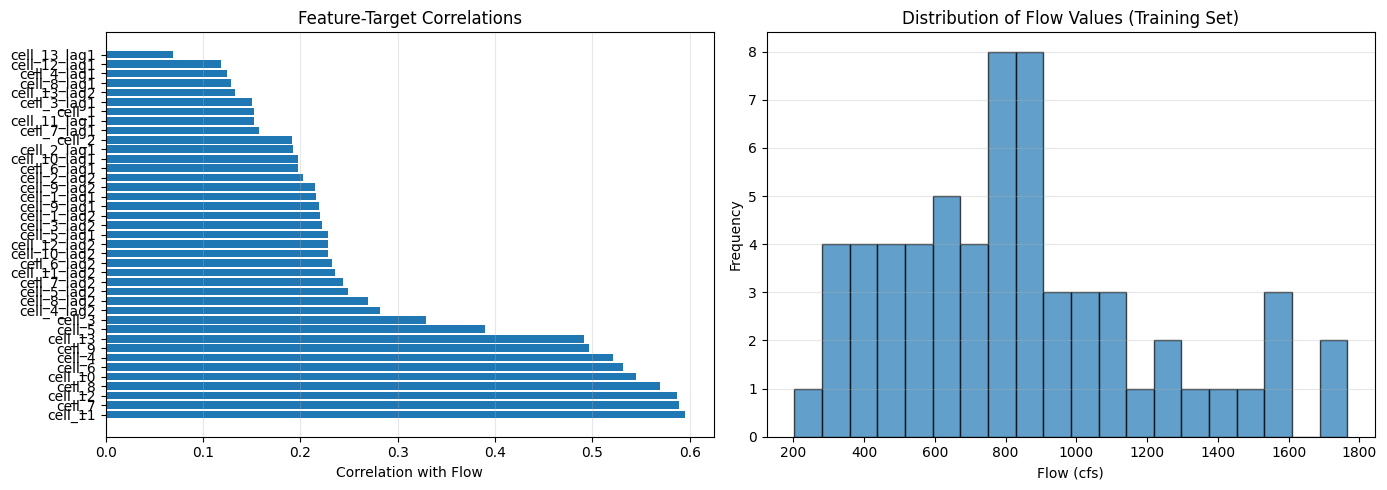

In [8]:
## VISUALIZE CORRELATIONS ##
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_matrix = X_train_imputed.corrwith(y_train).sort_values(key=abs, ascending=False)
axes[0].barh(range(len(corr_matrix)), corr_matrix.values)
axes[0].set_yticks(range(len(corr_matrix)))
axes[0].set_yticklabels(corr_matrix.index)
axes[0].set_xlabel('Correlation with Flow')
axes[0].set_title('Feature-Target Correlations')
axes[0].axvline(x=0, color='k', linestyle='--', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Distribution of target
axes[1].hist(y_train, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Flow (cfs)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Flow Values (Training Set)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
## HYPERPARAMETER TUNING - RANDOM FOREST ##
print("="*60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("="*60)

rf_param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

print("Performing Grid Search (this may take a few minutes)...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_imputed, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV R² score: {rf_grid.best_score_:.3f}")

# Test on holdout set
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_imputed)
print(f"Test R²: {r2_score(y_test, y_pred_rf):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_rf, squared=False):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")


RANDOM FOREST HYPERPARAMETER TUNING
Performing Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Best CV R² score: 0.197
Test R²: -0.018
Test RMSE: 337.067
Test MAE: 280.622


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [10]:
## HYPERPARAMETER TUNING - GRADIENT BOOSTING ##
print("="*60)
print("GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("="*60)

gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

print("Performing Grid Search...")
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train_imputed, y_train)

print(f"\nBest parameters: {gb_grid.best_params_}")
print(f"Best CV R² score: {gb_grid.best_score_:.3f}")

gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test_imputed)
print(f"Test R²: {r2_score(y_test, y_pred_gb):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_gb, squared=False):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_gb):.3f}")


GRADIENT BOOSTING HYPERPARAMETER TUNING
Performing Grid Search...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.8}
Best CV R² score: 0.041
Test R²: 0.022
Test RMSE: 330.364
Test MAE: 283.891


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [11]:
## HYPERPARAMETER TUNING - XGBOOST ##
print("="*60)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*60)

xgb_param_grid = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

print("Performing Grid Search...")
xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_imputed, y_train)

print(f"\nBest parameters: {xgb_grid.best_params_}")
print(f"Best CV R² score: {xgb_grid.best_score_:.3f}")

xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_imputed)
print(f"Test R²: {r2_score(y_test, y_pred_xgb):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_xgb, squared=False):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_xgb):.3f}")


XGBOOST HYPERPARAMETER TUNING
Performing Grid Search...
Fitting 5 folds for each of 972 candidates, totalling 4860 fits

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.7}
Best CV R² score: 0.105
Test R²: 0.094
Test RMSE: 318.021
Test MAE: 268.990


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [12]:
## HYPERPARAMETER TUNING - MLP ##
print("="*60)
print("MLP (NEURAL NETWORK) HYPERPARAMETER TUNING")
print("="*60)

# Scale the data (MLP requires scaled features)
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50), (64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [1000]
}

print("Performing Grid Search...")
mlp_grid = GridSearchCV(
    MLPRegressor(random_state=42, early_stopping=True),
    mlp_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
mlp_grid.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {mlp_grid.best_params_}")
print(f"Best CV R² score: {mlp_grid.best_score_:.3f}")

mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)
print(f"Test R²: {r2_score(y_test, y_pred_mlp):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_mlp, squared=False):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_mlp):.3f}")


MLP (NEURAL NETWORK) HYPERPARAMETER TUNING
Performing Grid Search...
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterat


Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.001, 'max_iter': 1000}
Best CV R² score: -0.780
Test R²: -0.772
Test RMSE: 444.685
Test MAE: 322.884


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


TUNED MODEL COMPARISON

            Model   Test_R2  Test_RMSE   Test_MAE
         XGBoost  0.093952 318.020643 268.990021
GradientBoosting  0.022254 330.363915 283.890751
    RandomForest -0.017827 337.067207 280.621783
             MLP -0.771521 444.685241 322.884364


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_reg

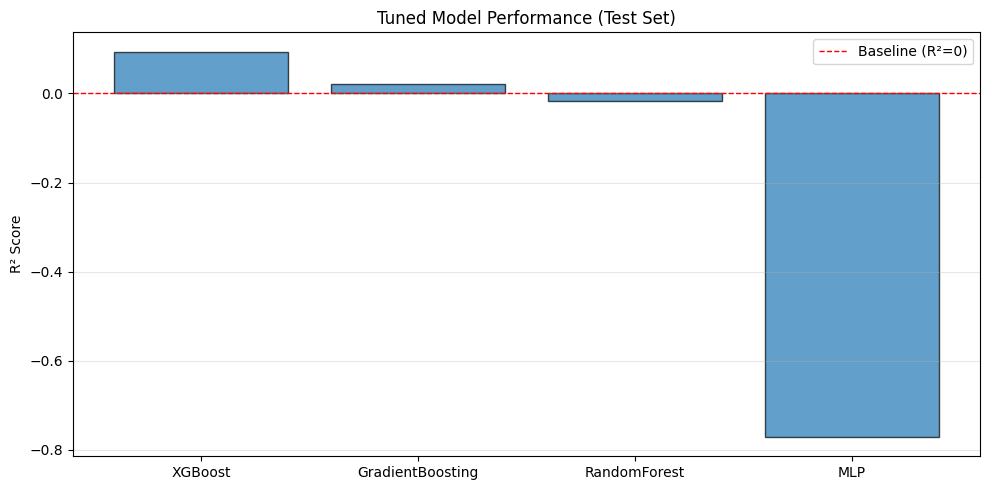

In [13]:
## COMPARE TUNED MODELS ##
print("="*60)
print("TUNED MODEL COMPARISON")
print("="*60)

tuned_models = {
    "RandomForest": (rf_best, X_test_imputed),
    "GradientBoosting": (gb_best, X_test_imputed),
    "XGBoost": (xgb_best, X_test_imputed),
    "MLP": (mlp_best, X_test_scaled)
}

tuned_results = []
for name, (model, X_pred) in tuned_models.items():
    y_pred = model.predict(X_pred)
    tuned_results.append({
        "Model": name,
        "Test_R2": r2_score(y_test, y_pred),
        "Test_RMSE": mean_squared_error(y_test, y_pred, squared=False),
        "Test_MAE": mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(tuned_results).sort_values('Test_R2', ascending=False)
print("\n", results_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(results_df))
ax.bar(x_pos, results_df['Test_R2'], alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'])
ax.set_ylabel('R² Score')
ax.set_title('Tuned Model Performance (Test Set)')
ax.axhline(y=0, color='r', linestyle='--', linewidth=1, label='Baseline (R²=0)')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE ANALYSIS

Analyzing best model: XGBoost

Feature Importances:
     Feature  Importance
     cell_12    0.063732
      cell_7    0.063115
 cell_8_lag2    0.058160
     cell_11    0.050958
      cell_6    0.049221
      cell_4    0.040664
     cell_10    0.038932
cell_10_lag1    0.037769
 cell_4_lag2    0.037745
cell_12_lag1    0.029668
 cell_1_lag2    0.028147
     cell_13    0.026393
 cell_6_lag1    0.024932
 cell_3_lag2    0.024304
      cell_5    0.022877
 cell_5_lag2    0.022758
 cell_8_lag1    0.022539
 cell_4_lag1    0.021378
cell_13_lag1    0.021181
 cell_7_lag2    0.021114
 cell_9_lag1    0.020757
cell_11_lag1    0.020664
      cell_3    0.020337
cell_10_lag2    0.018760
 cell_1_lag1    0.017817
 cell_3_lag1    0.017677
 cell_5_lag1    0.016887
cell_11_lag2    0.016540
 cell_6_lag2    0.016070
 cell_9_lag2    0.015991
 cell_2_lag1    0.015639
      cell_8    0.014358
 cell_2_lag2    0.013925
      cell_9    0.013508
cell_12_lag2    0.012623
      cell_1    0.0

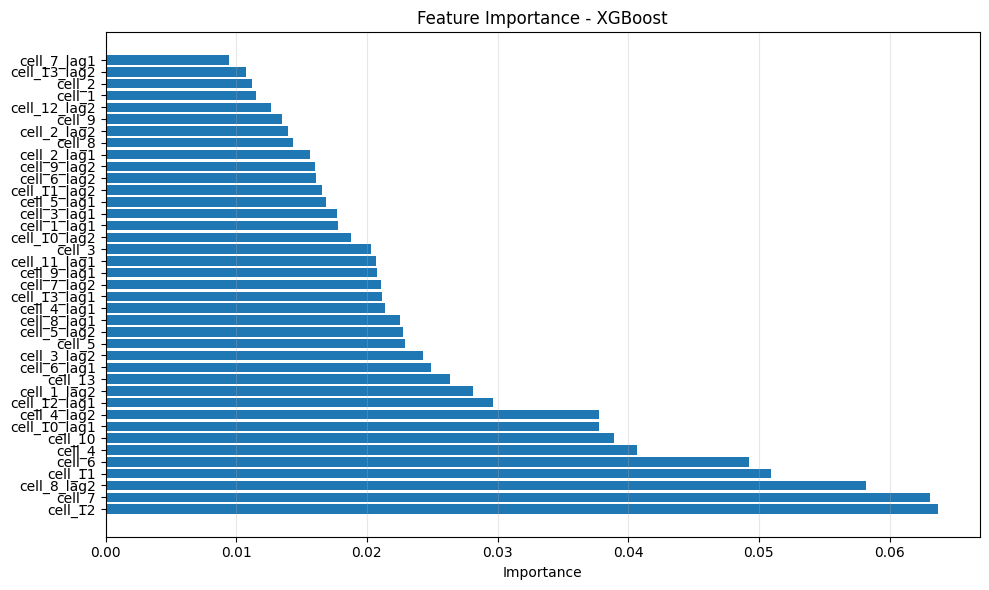

In [14]:
## FEATURE IMPORTANCE ANALYSIS ##
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name][0]
print(f"\nAnalyzing best model: {best_model_name}")

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importances.to_string(index=False))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(importances)), importances['Importance'])
    ax.set_yticks(range(len(importances)))
    ax.set_yticklabels(importances['Feature'])
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance - {best_model_name}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importances not available for this model type")


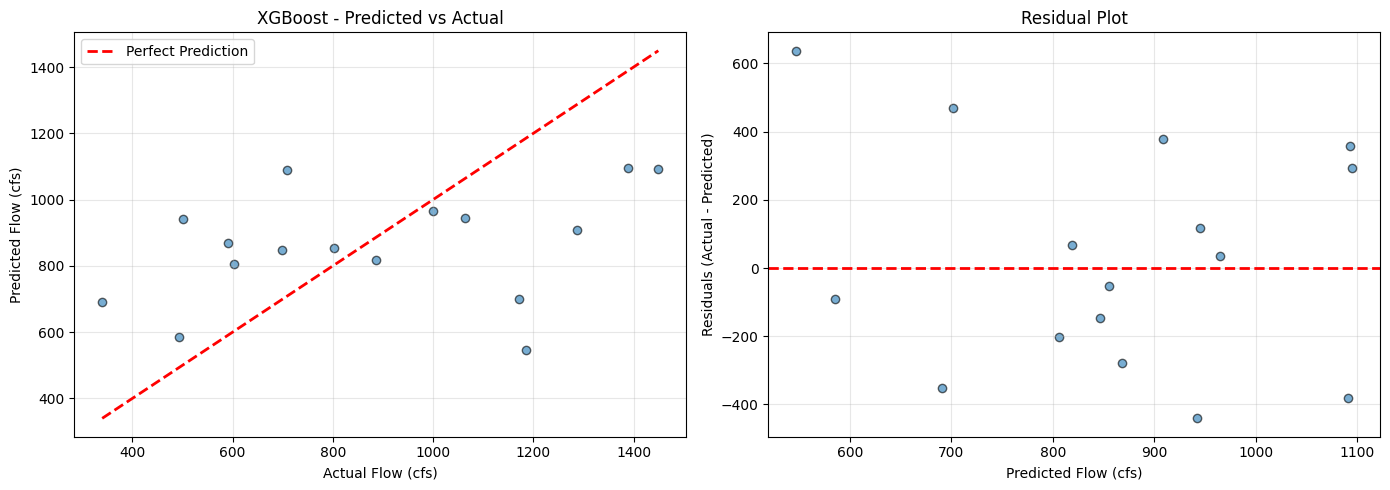

In [15]:
## PREDICTION ANALYSIS ##
# Plot predictions vs actual for best model
best_model = tuned_models[results_df.iloc[0]['Model']][0]
best_X_test = tuned_models[results_df.iloc[0]['Model']][1]
y_pred_best = best_model.predict(best_X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.6, edgecolor='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Flow (cfs)')
axes[0].set_ylabel('Predicted Flow (cfs)')
axes[0].set_title(f'{results_df.iloc[0]["Model"]} - Predicted vs Actual')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, edgecolor='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Flow (cfs)')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


LEARNING CURVE ANALYSIS
Generating learning curves to diagnose overfitting/underfitting...


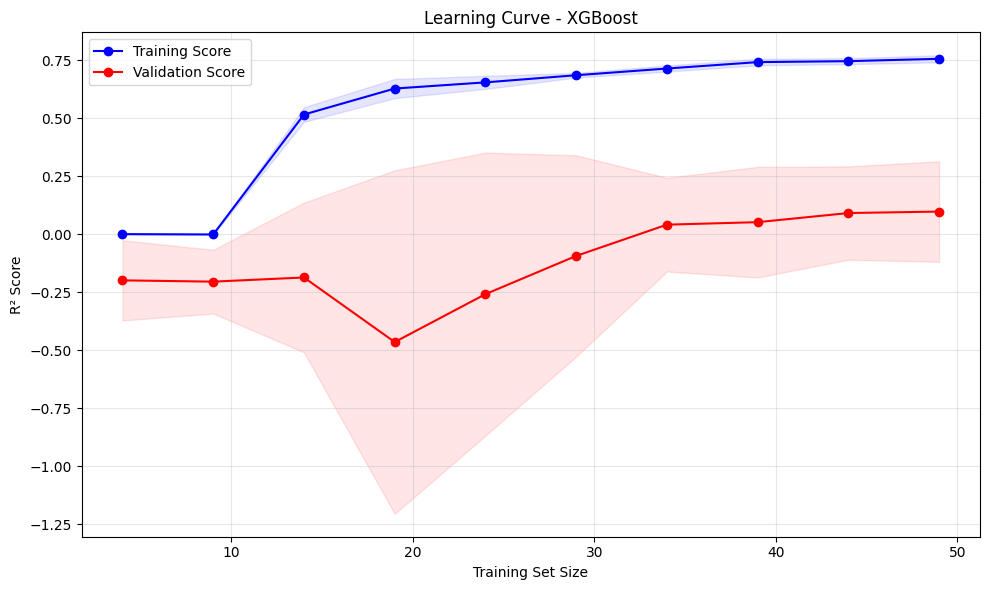


Final validation R²: 0.097 ± 0.217
⚠️  Large gap between training and validation suggests OVERFITTING
   Recommendation: Simplify model or add regularization


In [16]:
## LEARNING CURVE ANALYSIS ##
from sklearn.model_selection import learning_curve

print("="*60)
print("LEARNING CURVE ANALYSIS")
print("="*60)
print("Generating learning curves to diagnose overfitting/underfitting...")

# Use best model
best_estimator_type = type(best_model).__name__
if 'MLP' in best_estimator_type:
    base_model = MLPRegressor(**mlp_grid.best_params_, random_state=42)
    X_curve = X_train_scaled
elif 'XGB' in best_estimator_type:
    base_model = xgb.XGBRegressor(**xgb_grid.best_params_, random_state=42)
    X_curve = X_train_imputed
elif 'Gradient' in best_estimator_type:
    base_model = GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)
    X_curve = X_train_imputed
else:
    base_model = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
    X_curve = X_train_imputed

train_sizes, train_scores, val_scores = learning_curve(
    base_model, X_curve, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.1, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title(f'Learning Curve - {results_df.iloc[0]["Model"]}')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print(f"\nFinal validation R²: {val_mean[-1]:.3f} ± {val_std[-1]:.3f}")
if train_mean[-1] - val_mean[-1] > 0.2:
    print("⚠️  Large gap between training and validation suggests OVERFITTING")
    print("   Recommendation: Simplify model or add regularization")
elif val_mean[-1] < 0.3:
    print("⚠️  Low validation score suggests UNDERFITTING or INSUFFICIENT DATA")
    print("   Recommendations:")
    print("   - Collect more calibration data")
    print("   - Engineer new features")
    print("   - Check if predictors are relevant to target")
else:
    print("✓ Model appears reasonably well-fitted")


In [17]:
## FINAL RECOMMENDATIONS ##
print("="*60)
print("FINAL ASSESSMENT AND RECOMMENDATIONS")
print("="*60)

best_r2 = results_df.iloc[0]['Test_R2']
n_samples = len(X_train)
n_features = X_train.shape[1]

print(f"\n1. Best Model: {results_df.iloc[0]['Model']}")
print(f"   Test R²: {best_r2:.3f}")
print(f"   Test RMSE: {results_df.iloc[0]['Test_RMSE']:.2f} cfs")

print(f"\n2. Data Sufficiency:")
print(f"   Samples: {n_samples}")
print(f"   Features: {n_features}")
print(f"   Samples/Features ratio: {n_samples/n_features:.1f}")

if n_samples < 100:
    print("   ⚠️  Very small sample size - results may be unreliable")
elif n_samples/n_features < 5:
    print("   ⚠️  Low samples-to-features ratio - consider feature selection")

if best_r2 < 0.3:
    print("\n3. Performance Assessment: POOR")
    print("   Possible reasons:")
    print("   - Insufficient calibration data")
    print("   - Weak relationship between tree-ring cells and streamflow")
    print("   - Wrong spatial cells selected (not capturing relevant climate)")
    print("   - Need temporal lags or seasonal features")
    print("\n   Recommendations:")
    print("   ✓ Check if selected cells are in the watershed or climatically relevant")
    print("   ✓ Try adding lagged predictor values (t-1, t-2 years)")
    print("   ✓ Consider using nearby gauge data for additional calibration")
    print("   ✓ Explore polynomial or interaction features")
    print("   ✓ Collect more observed flow data if possible")
elif best_r2 < 0.5:
    print("\n3. Performance Assessment: MODERATE")
    print("   The model has some predictive power but may not be reliable for all applications")
    print("\n   Recommendations:")
    print("   ✓ Add feature engineering (lags, interactions)")
    print("   ✓ Verify spatial selection of tree-ring cells")
    print("   ✓ Consider ensemble methods or stacking")
else:
    print("\n3. Performance Assessment: GOOD")
    print("   The model shows reasonable predictive capability")
    print("\n   Recommendations:")
    print("   ✓ Validate on independent data if available")
    print("   ✓ Check for temporal stability (split by time periods)")
    print("   ✓ Document uncertainty in reconstructions")


FINAL ASSESSMENT AND RECOMMENDATIONS

1. Best Model: XGBoost
   Test R²: 0.094
   Test RMSE: 318.02 cfs

2. Data Sufficiency:
   Samples: 62
   Features: 39
   Samples/Features ratio: 1.6
   ⚠️  Very small sample size - results may be unreliable

3. Performance Assessment: POOR
   Possible reasons:
   - Insufficient calibration data
   - Weak relationship between tree-ring cells and streamflow
   - Wrong spatial cells selected (not capturing relevant climate)
   - Need temporal lags or seasonal features

   Recommendations:
   ✓ Check if selected cells are in the watershed or climatically relevant
   ✓ Try adding lagged predictor values (t-1, t-2 years)
   ✓ Consider using nearby gauge data for additional calibration
   ✓ Explore polynomial or interaction features
   ✓ Collect more observed flow data if possible


In [18]:
## BASELINE MODELS (BEFORE TUNING) ##
# This cell is kept for comparison - see tuned models above

rf_baseline = RandomForestRegressor(n_estimators=1000, random_state=42)
rf_baseline.fit(X_train_imputed, y_train)

y_pred = rf_baseline.predict(X_test_imputed)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Baseline Random Forest – R² = {r2:.3f}, RMSE = {rmse:.3f}")
print("(See tuned models above for improved performance)")


Baseline Random Forest – R² = -0.137, RMSE = 356.296
(See tuned models above for improved performance)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [19]:
## BASELINE GRADIENT BOOSTING AND XGBOOST ##
gb_baseline = GradientBoostingRegressor(random_state=42)
gb_baseline.fit(X_train_imputed, y_train)
print("Baseline GB R²:", r2_score(y_test, gb_baseline.predict(X_test_imputed)))

xg_baseline = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42
)
xg_baseline.fit(X_train_imputed, y_train)
print("Baseline XGB R²:", r2_score(y_test, xg_baseline.predict(X_test_imputed)))
print("(See tuned models above for improved performance)")


Baseline GB R²: -0.03905650560109386
Baseline XGB R²: 0.016867419101493586
(See tuned models above for improved performance)


In [20]:
## BASELINE MLP ##
# Create scaled data if not already created (from MLP tuning cell)
if 'X_train_scaled' not in locals():
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed)

mlp_baseline = MLPRegressor(hidden_layer_sizes=(64,32), activation="relu",
                   solver="adam", max_iter=500, random_state=42)
mlp_baseline.fit(X_train_scaled, y_train)
print("Baseline MLP R²:", r2_score(y_test, mlp_baseline.predict(X_test_scaled)))
print("(See tuned models above for improved performance)")


Baseline MLP R²: -0.2689598014153669
(See tuned models above for improved performance)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



Baseline vs Tuned Model Comparison:
                      Model        R2       RMSE
            XGBoost (Tuned)  0.093952 318.020643
   GradientBoosting (Tuned)  0.022254 330.363915
         XGBoost (Baseline)  0.016867 331.272714
       RandomForest (Tuned) -0.017827 337.067207
GradientBoosting (Baseline) -0.039057 340.564366
    RandomForest (Baseline) -0.137268 356.296111
             MLP (Baseline) -0.268960 376.360082
                MLP (Tuned) -0.771521 444.685241


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_reg

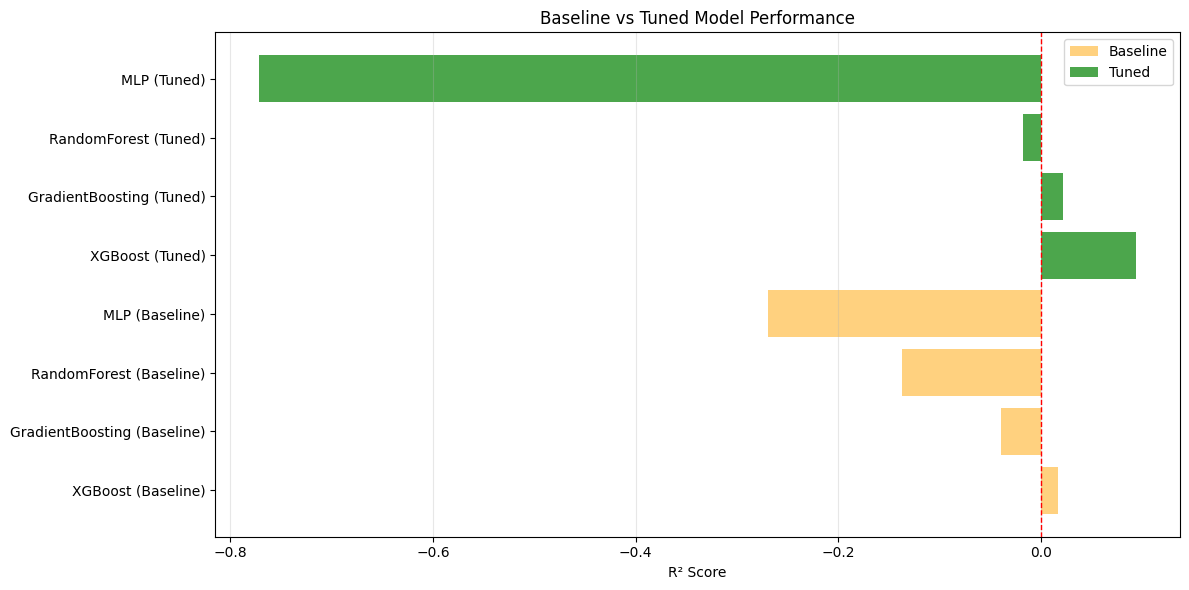

In [21]:
## COMPARE BASELINE VS TUNED MODELS ##
baseline_models = {
    "RandomForest (Baseline)": (rf_baseline, X_test_imputed),
    "RandomForest (Tuned)": (rf_best, X_test_imputed),
    "GradientBoosting (Baseline)": (gb_baseline, X_test_imputed),
    "GradientBoosting (Tuned)": (gb_best, X_test_imputed),
    "XGBoost (Baseline)": (xg_baseline, X_test_imputed),
    "XGBoost (Tuned)": (xgb_best, X_test_imputed),
    "MLP (Baseline)": (mlp_baseline, X_test_scaled),
    "MLP (Tuned)": (mlp_best, X_test_scaled)
}

comparison_results = []
for name, (m, X_pred) in baseline_models.items():
    yhat = m.predict(X_pred)
    comparison_results.append({
        "Model": name,
        "R2": r2_score(y_test, yhat),
        "RMSE": mean_squared_error(y_test, yhat, squared=False)
    })
    
comparison_df = pd.DataFrame(comparison_results).sort_values('R2', ascending=False)
print("\nBaseline vs Tuned Model Comparison:")
print(comparison_df.to_string(index=False))

# Visualize improvement
fig, ax = plt.subplots(figsize=(12, 6))
baseline_idx = [i for i, name in enumerate(comparison_df['Model']) if 'Baseline' in name]
tuned_idx = [i for i, name in enumerate(comparison_df['Model']) if 'Tuned' in name]

ax.barh([comparison_df.iloc[i]['Model'] for i in baseline_idx], 
        [comparison_df.iloc[i]['R2'] for i in baseline_idx], 
        alpha=0.5, label='Baseline', color='orange')
ax.barh([comparison_df.iloc[i]['Model'] for i in tuned_idx], 
        [comparison_df.iloc[i]['R2'] for i in tuned_idx], 
        alpha=0.7, label='Tuned', color='green')
ax.set_xlabel('R² Score')
ax.set_title('Baseline vs Tuned Model Performance')
ax.axvline(x=0, color='r', linestyle='--', linewidth=1)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


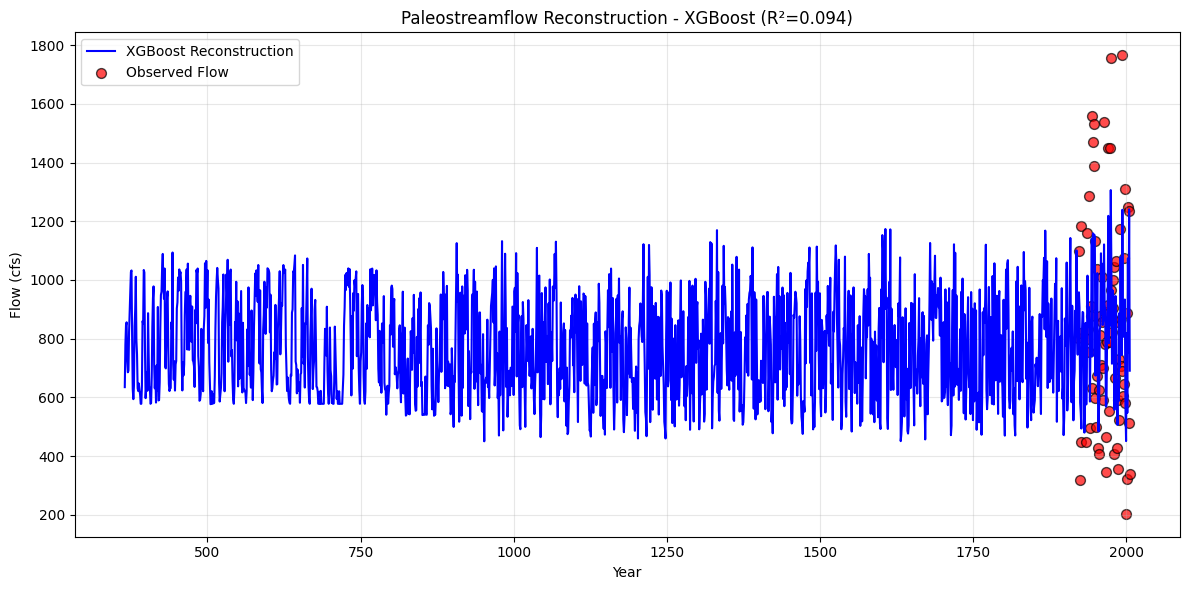

In [22]:
## FINAL RECONSTRUCTION WITH BEST MODEL ##
# Use the best tuned model for reconstruction
best_model_for_recon = tuned_models[results_df.iloc[0]['Model']][0]

# Scale full dataset if best model is MLP (scaler was fitted in MLP tuning cell)
if results_df.iloc[0]['Model'] == 'MLP':
    X_full_scaled = scaler.transform(X_full_imputed)
    best_X_full = X_full_scaled
else:
    best_X_full = X_full_imputed

full_pred = best_model_for_recon.predict(best_X_full)
df["recon_flow_best"] = full_pred

plt.figure(figsize=(12,6))
plt.plot(years_full, full_pred, label=f"{results_df.iloc[0]['Model']} Reconstruction", color="blue", linewidth=1.5)
plt.scatter(years_cal, y_cal, color="red", s=50, label="Observed Flow", alpha=0.7, edgecolor='black')
plt.legend()
plt.title(f"Paleostreamflow Reconstruction - {results_df.iloc[0]['Model']} (R²={results_df.iloc[0]['Test_R2']:.3f})")
plt.xlabel("Year")
plt.ylabel("Flow (cfs)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
## SAVE BEST MODEL RECONSTRUCTION ##
best_model_name_clean = results_df.iloc[0]['Model'].replace(' ', '_')
output_filename = f"gage02361000_{best_model_name_clean}_reconstruction.csv"

df_out = df[["year", "flow_cfs", "recon_flow_best"]]
df_out.rename(columns={"recon_flow_best": f"recon_flow_{best_model_name_clean}"}, inplace=True)
df_out.to_csv(output_filename, index=False)
print(f"Saved: {output_filename}")
print(f"\nBest Model: {results_df.iloc[0]['Model']}")
print(f"Test R²: {results_df.iloc[0]['Test_R2']:.3f}")
print(f"Test RMSE: {results_df.iloc[0]['Test_RMSE']:.2f} cfs")


Saved: gage02361000_XGBoost_reconstruction.csv

Best Model: XGBoost
Test R²: 0.094
Test RMSE: 318.02 cfs


/var/folders/fk/9vtsjr3s2ls08lw74pyqgbnh0000gn/T/ipykernel_76685/2414284580.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out.rename(columns={"recon_flow_best": f"recon_flow_{best_model_name_clean}"}, inplace=True)


In [24]:
## HOW TO INTERPRET THE RESULTS ##

print("="*60)
print("GUIDE TO INTERPRETING YOUR RESULTS")
print("="*60)

print("""
This notebook now provides comprehensive model tuning and diagnostics:

1. DATA QUALITY ASSESSMENT (Cell 5):
   - Check sample size and missing data patterns
   - Review correlations between predictors and target
   - Compare to baseline (predicting mean)
   
2. HYPERPARAMETER TUNING (Cells 7-10):
   - Each model is tuned using GridSearchCV with 5-fold cross-validation
   - Best parameters are automatically selected
   - Test set performance shows how well the model generalizes
   
3. MODEL COMPARISON (Cell 11):
   - Compares all tuned models side-by-side
   - Use the best-performing model for your reconstruction
   
4. FEATURE IMPORTANCE (Cell 12):
   - Shows which tree-ring cells are most predictive
   - Helps validate that your spatial selection makes sense
   
5. LEARNING CURVES (Cell 14):
   - Diagnoses overfitting (training >> validation)
   - Diagnoses underfitting (both scores are low)
   - Shows if more data would help
   
6. FINAL RECOMMENDATIONS (Cell 15):
   - Automated assessment of model quality
   - Specific suggestions for improvement

KEY QUESTIONS TO ASK:
- Is my R² > 0.3? If not, the model has weak predictive power
- Are my correlations > 0.3? If not, predictors may not be relevant
- Do I have enough data? (aim for 10+ samples per feature)
- Is there a large train-validation gap? (suggests overfitting)
- Which cells are most important? (should be near watershed)

NEXT STEPS IF RESULTS ARE POOR:
1. Add more observed flow data for calibration
2. Select different tree-ring cells (closer to watershed)
3. Add temporal lags (previous year's climate affects flow)
4. Try feature engineering (interactions, polynomials)
5. Consider if streamflow can be reconstructed from tree rings
   (works best for snowmelt-dominated systems)
""")

print("="*60)


GUIDE TO INTERPRETING YOUR RESULTS

This notebook now provides comprehensive model tuning and diagnostics:

1. DATA QUALITY ASSESSMENT (Cell 5):
   - Check sample size and missing data patterns
   - Review correlations between predictors and target
   - Compare to baseline (predicting mean)

2. HYPERPARAMETER TUNING (Cells 7-10):
   - Each model is tuned using GridSearchCV with 5-fold cross-validation
   - Best parameters are automatically selected
   - Test set performance shows how well the model generalizes

3. MODEL COMPARISON (Cell 11):
   - Compares all tuned models side-by-side
   - Use the best-performing model for your reconstruction

4. FEATURE IMPORTANCE (Cell 12):
   - Shows which tree-ring cells are most predictive
   - Helps validate that your spatial selection makes sense

5. LEARNING CURVES (Cell 14):
   - Diagnoses overfitting (training >> validation)
   - Diagnoses underfitting (both scores are low)
   - Shows if more data would help

6. FINAL RECOMMENDATIONS (Cell 15